## Check the Qutip Class: Phase diagram of the Steady states

#### Imports



In [1]:
import numpy as np
import qutip
from qutip import concurrence
from qutip_class import IsingHamiltonian,SteadyStateSolver,AbstractOperator
import matplotlib.pyplot as plt

### Abstract Operator: how it works and why

The Qutip library is focused on numerical tools and methods for Open Quantum System. The aim of this notebook is to show how we can envelope Qutip in a Many-Body fashion.

Furthermore, we develop a Steady State Solver Class. 

In general a Many-Body operator can be described as a linear combination of local operators tensor products

\begin{equation}
    \hat{O}=\sum_{i j k l} g_{ijkl} \hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l}
\end{equation}

where $A$, $B$, $C$ and $D$ are local operators in a given representation (Fock, Spin, etc...). 

We can then decompose an operator as sum of a density operator

\begin{equation}
    \hat{O}=\sum_{i j k l} g_{ijkl} \hat{O}_{i j k l},
\end{equation}

where 

\begin{equation}
    \hat{O}_{ijkl}=  \hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l}.
\end{equation}

Following this consideration, an Operator can be described as a list of "localized" operators that act in a sum. Each localized operator is described by a tuple of indices, a list of local basis operators and a scalar value 

\begin{equation}
    g_{ijkl}\hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l} \rightarrow [i,j,k,l], \; [A,B,C,D], \; \; g_{ijkl}.
\end{equation}

Therefore, The Abstract Operator Class is characterized by a list of localized observables, with three parameters:

-) Index [ List of Tuples]: The list of indices in which the local operator acts.
-) Direction [ List of List of strings ]: the list of local basis operators described by strings. They are:

                                    ['id','x','y','z','+','-','a','a_dag','id_fock'].
The first 6 strings represent the spin representation basis, the last free the Fock representation basis.

-) Coupling [ List of floats]: coefficients of the linear combination of the localized operators

#### Example of Abstract Operator

Now, we show how to define a simple Ising coupling term as

\begin{equation}
    H=J\sum^{2}_{i=0} X_i X_{i+1} 
\end{equation}

in periodic boundary conditions.

Data

In [3]:
# sites
l=3

# indices
# 1nn coupling term in pbc
idx=[(0,1),(1,2),(2,0)]

# or even better
idx=[(i,(i+1)%l) for i in range(l)]

# type of coupling
# along the x direction
# the loop is because the
# number of localized operators
# is 3.
dir=[['x','x'] for i in range(l)]

# the coupling is J=1
coupling=[1 for i in range(l)]

# define the abstract operator
# as xx_ao
xx_ao=AbstractOperator(index=idx,direction=dir,coupling=coupling,size=l)

# the printout method
# gives a description
# of the operator as
# a dictionary in the
# indeces

xx_ao.printout()



 

{(0, 1): {'coupling': 1, 'direction': ['x', 'x']}, (1, 2): {'coupling': 1, 'direction': ['x', 'x']}, (2, 0): {'coupling': 1, 'direction': ['x', 'x']}}


#### Attributes of the Abstract Operator

The Abstract operator embedded a general many-body Qutip Object in a more compact form. The methods and attributes are few and simple.  

-)Append

Suppose we want to add to the operator $H$ an external field operator $V=h \sum^{2}_{i=0} Z_i$. In this case we can use the append attribute

In [6]:
# define the AO
idx=[(i,) for i in range(l)]
coupling=[1 for i in range(l)]
direction=[['z'] for i in range(l)]
z_ao=AbstractOperator(index=idx,direction=direction,coupling=coupling,size=l)

# Append to the xx
# term
xx_ao.append(ao=z_ao)

# print the new
# AO
xx_ao.printout()

{(0, 1): {'coupling': 1, 'direction': ['x', 'x']}, (1, 2): {'coupling': 1, 'direction': ['x', 'x']}, (2, 0): {'coupling': 1, 'direction': ['x', 'x']}, (0,): {'coupling': 1, 'direction': ['z']}, (1,): {'coupling': 1, 'direction': ['z']}, (2,): {'coupling': 1, 'direction': ['z']}}


-) Expt value and Expt value density

Another important methods is the Expectation value. With a given state $\ket{\phi}$, it returns the expectation value:

\begin{equation}
    \braket{\hat{O}}= \sum_{ijkl} g_{ijkl} \braket{A_i B_j C_k D_l}.
\end{equation}

Sometimes, we want to study the expectation value of an operator per site (Correlation functions, magnetizations, etc...). In this case we need to collect the expectation value of each localized operators into a list

\begin{equation}
    T_{ijkl}=g_{ijkl}\braket{O_{ijkl}}
\end{equation}

In [16]:
# define the full
# spin up state | 1, 1, 1>
# as a qutip object
psi=qutip.basis(2)
psi_2=qutip.tensor(psi,psi)
psi_3=qutip.tensor(psi_2,psi)

# AO representation
xx_ao.printout()
print('\n')

# expt value of Jxx+hz
xx_z=xx_ao.expect_value(psi=psi_3)
print('expect value=',xx_z,'\n')

# expt per site of {Jxx,hz} as a dictionary
# in the indices keys
den_xx_z=xx_ao.expect_value_density(psi=psi_3)
print('expect value per site=',den_xx_z)




{(0, 1): {'coupling': 1, 'direction': ['x', 'x']}, (1, 2): {'coupling': 1, 'direction': ['x', 'x']}, (2, 0): {'coupling': 1, 'direction': ['x', 'x']}, (0,): {'coupling': 1, 'direction': ['z']}, (1,): {'coupling': 1, 'direction': ['z']}, (2,): {'coupling': 1, 'direction': ['z']}}


expect value= 3.0 

expect value per site= {(0, 1): 0.0, (1, 2): 0.0, (2, 0): 0.0, (0,): 1.0, (1,): 1.0, (2,): 1.0}


#### Define the Ising hamiltonian in the critical configuration $J=1$, $h=1$

Parameter

In [3]:
size=5
hs=np.linspace(0,5,30)

Dissipative term

In [4]:
n_dissipative=size
couplings=[1]*size
directions=[['+','-']]*size
index=[(i,(i+1)%size) for i in range(size)]

#create the list of dissipators
cs=[]
for i in range(n_dissipative):
    # for each site
    print(index[i],directions[i],couplings[i])
    cs.append(AbstractOperator([index[i]],direction=[directions[i]],coupling=[couplings[i]],size=size))

(0, 1) ['+', '-'] 1
(1, 2) ['+', '-'] 1
(2, 3) ['+', '-'] 1
(3, 4) ['+', '-'] 1
(4, 0) ['+', '-'] 1


In [5]:

ent=[]
for h in hs:

    print(h)
    h_ising_c=IsingHamiltonian(direction_coupling=('z','z'),field_direction='x',j=1,h=h,size=size)
    sss=SteadyStateSolver(hamiltonian=h_ising_c,dissipative_ops=cs)
    sss.get_steady_state()
    y=sss.entanglement_entropy(size_a=1)
    ent.append(y)
    print(y)
    




0.0
0.9709505944546687
0.1724137931034483
0.9999999999999998
0.3448275862068966
1.0
0.5172413793103449
0.9999999999999999
0.6896551724137931
1.0
0.8620689655172414
1.0
1.0344827586206897
0.9999999999999999
1.206896551724138
1.0
1.3793103448275863
1.0
1.5517241379310347
1.0
1.7241379310344829
1.0
1.896551724137931
1.0
2.0689655172413794
1.0
2.241379310344828
1.0
2.413793103448276
1.0
2.586206896551724
1.0
2.7586206896551726
0.9999999999999998
2.931034482758621
0.9999999999999999
3.1034482758620694
1.0
3.2758620689655173
0.9999999999999999
3.4482758620689657
1.0
3.620689655172414
1.0
3.793103448275862
1.0
3.9655172413793105
1.0
4.137931034482759
1.0
4.310344827586207
0.6285683085890097
4.482758620689656
-0.025048609203595355
4.655172413793104
0.9997010838782686
4.827586206896552


Exception: Zero pivot, numerical factorization or iterative refinement problem

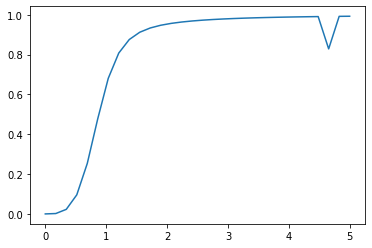

In [7]:
plt.plot(hs[:len(ent)],ent)

In [5]:
h_ising_c.printout()

print(h_ising_c.qutip_op)

Coupling Term: 

[((0, 1), {'coupling': 1, 'direction': ['z', 'z']})] 

External field: 

[((0,), {'coupling': 1, 'direction': ['x']}), ((1,), {'coupling': 1, 'direction': ['x']})] 

Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[ 1.  1.  1.  0.]
 [ 1. -1.  0.  1.]
 [ 1.  0. -1.  1.]
 [ 0.  1.  1.  1.]]
